In [ ]:
!pip install librosa -q

# Drone Acoustic Detection System
## Phase 1: Data Exploration

Building an audio-based drone detection system that identifies drones by their sound signature. Using the DroneAudioDataset a well-cited dataset from IWCMC 2019, containing recordings of two drone types (Bebop, Mambo) and non-drone sounds.


In [2]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from IPython.display import Audio

### Downloading the dataset

Cloning the DroneAudioDataset from GitHub, ~200 MB of WAV files organized into Binary and Multiclass folders.

In [3]:
!git clone https://github.com/saraalemadi/DroneAudioDataset.git ./data/DroneAudioDataset

Cloning into './data/DroneAudioDataset'...
remote: Enumerating objects: 10649, done.
remote: Counting objects: 100% (6/6), done.
remote: Total 10649 (delta 5), reused 5 (delta 5), pack-reused 10643 (from 1)
Receiving objects: 100% (10649/10649), 274.31 MiB | 13.33 MiB/s, done.
Resolving deltas: 100% (181/181), done.
Updating files: 100% (23409/23409), done.


### Exploring the folder structure

Looking at how the files are organized before writing any processing code.

In [23]:
for root, dirs, files in os.walk("./data/DroneAudioDataset"):
    dirs[:] = [d for d in dirs if d != '.git']
    level = root.replace("./data/DroneAudioDataset", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        for f in files[:3]:
            print(f"{indent}  {f}")
        if len(files) > 3:
            print(f"{indent}  ... and {len(files) - 3} more files")

DroneAudioDataset/
  README.md
  Multiclass_Drone_Audio/
    bebop_1/
      mixed_49-bebop_001_.wav
      B_S2_D1_114-bebop_001_.wav
      mixed_33-bebop_004_.wav
      ... and 663 more files
    unknown/
      2-102414-G-171.wav
      2-112213-B-393.wav
      4-141365-A-182.wav
      ... and 10369 more files
    membo_1/
      Membo_1_033-membo_004_.wav
      extra_membo_D2_2050.wav
      Membo_0_008-membo_004_.wav
      ... and 663 more files
  Binary_Drone_Audio/
    yes_drone/
      mixed_49-bebop_001_.wav
      Membo_1_033-membo_004_.wav
      extra_membo_D2_2050.wav
      ... and 1329 more files
    unknown/
      2-102414-G-171.wav
      2-112213-B-393.wav
      4-141365-A-182.wav
      ... and 10369 more files


### Counting samples per class

Checking how many audio files exist in each category for both the binary and multiclass setups.

In [5]:
binary_path = "./data/DroneAudioDataset/Binary_Drone_Audio"
multi_path = "./data/DroneAudioDataset/Multiclass_Drone_Audio"

print("=== Binary ===")
for folder in os.listdir(binary_path):
    folder_path = os.path.join(binary_path, folder)
    if os.path.isdir(folder_path):
        count = len([f for f in os.listdir(folder_path) if f.endswith('.wav')])
        print(f"  {folder}: {count}")

print("\n=== Multiclass ===")
for folder in os.listdir(multi_path):
    folder_path = os.path.join(multi_path, folder)
    if os.path.isdir(folder_path):
        count = len([f for f in os.listdir(folder_path) if f.endswith('.wav')])
        print(f"  {folder}: {count}")

=== Binary ===
  yes_drone: 1332
  unknown: 10372

=== Multiclass ===
  bebop_1: 666
  unknown: 10372
  membo_1: 666


### Listening to the samples

Playing one audio file from each class to build intuition for what the model will try to learn.

In [6]:
# Pick one sample from each multiclass folder
sample_paths = {
    "bebop": "./data/DroneAudioDataset/Multiclass_Drone_Audio/bebop_1",
    "membo": "./data/DroneAudioDataset/Multiclass_Drone_Audio/membo_1",
    "unknown": "./data/DroneAudioDataset/Multiclass_Drone_Audio/unknown"
}

for name, folder in sample_paths.items():
    # Getting the first .wav file in the folder
    first_file = sorted([f for f in os.listdir(folder) if f.endswith('.wav')])[0]
    filepath = os.path.join(folder, first_file)


    # y = audio signal as a numpy array
    # sr = sample rate (samples per second)
    # sr=None keeps the original sample rate
    y, sr = librosa.load(filepath, sr=None)

    print(f"{name} | Duration: {len(y)/sr:.2f}s | Sample rate: {sr} Hz")
    display(Audio(y, rate=sr))

bebop | Duration: 1.02s | Sample rate: 16000 Hz


membo | Duration: 1.02s | Sample rate: 16000 Hz


unknown | Duration: 1.02s | Sample rate: 16000 Hz


/usr/local/lib/python3.12/dist-packages/IPython/lib/display.py:174: RuntimeWarning: invalid value encountered in divide
  scaled = data / normalization_factor * 32767
/usr/local/lib/python3.12/dist-packages/IPython/lib/display.py:175: RuntimeWarning: invalid value encountered in cast
  return scaled.astype("<h").tobytes(), nchan


### Visualizing drone vs. non-drone audio

Comparing waveform, mel-spectrogram, and MFCC for each class. For unknown, I'm skipping silent files and picking one with actual audio content.

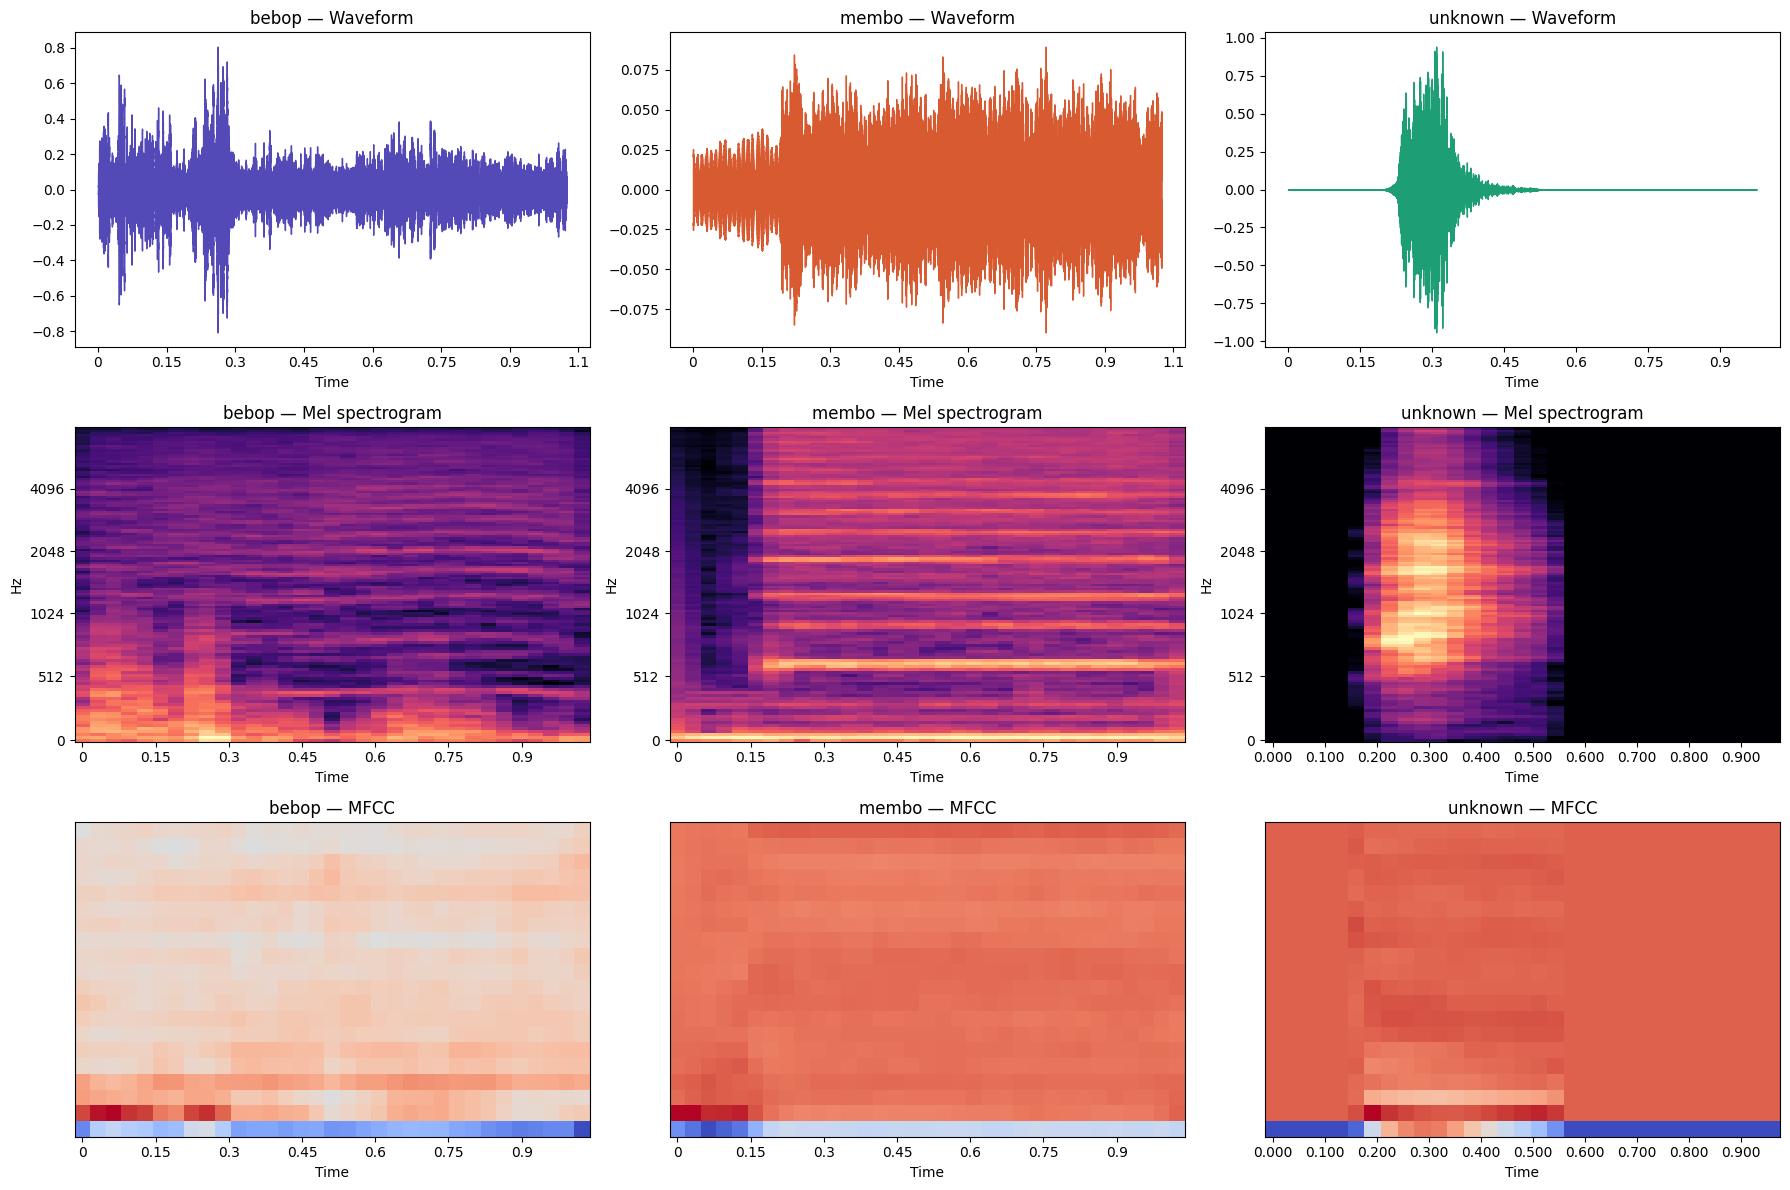

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
colors = ['#534AB7', '#D85A30', '#1D9E75']

# For bebop and membo, first file works fine
# For unknown, find a non-silent file
samples = {}
for name, folder in sample_paths.items():
    wav_files = sorted([f for f in os.listdir(folder) if f.endswith('.wav')])

    if name == "unknown":
        # Skip silent files — look for one with actual energy
        for f in wav_files:
            y_temp, _ = librosa.load(os.path.join(folder, f), sr=16000)
            if np.abs(y_temp).max() > 0.01:
                samples[name] = os.path.join(folder, f)
                break
    else:
        samples[name] = os.path.join(folder, wav_files[0])

for col, (name, filepath) in enumerate(samples.items()):
    y, sr = librosa.load(filepath, sr=16000)

    librosa.display.waveshow(y, sr=sr, ax=axes[0, col], color=colors[col])
    axes[0, col].set_title(f"{name} — Waveform")

    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128),
        ref=np.max
    )
    librosa.display.specshow(mel, sr=sr, x_axis='time', y_axis='mel',
                              ax=axes[1, col], cmap='magma')
    axes[1, col].set_title(f"{name} — Mel spectrogram")

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    librosa.display.specshow(mfcc, sr=sr, x_axis='time',
                              ax=axes[2, col], cmap='coolwarm')
    axes[2, col].set_title(f"{name} — MFCC")

plt.tight_layout()
plt.show()

### What I'm seeing

**Waveform:** Both drones (bebop and membo) show continuous, sustained vibration, the propellers are spinning constantly. The unknown sample is a short burst of energy that quickly dies out, likely an environmental sound like a door slam or a clap.

**Mel-spectrogram:** The drone signatures have clear horizontal bands that persist over time, these are the harmonic frequencies from the propeller RPM. Membo has a particularly bright band around 512 Hz. The unknown sample's energy is concentrated in a brief moment with no sustained frequency structure.

**MFCC:** The drone MFCC patterns stay stable across time, the color barely changes. The unknown MFCC shows a sharp shift from active to silent. This temporal consistency in drone sounds is exactly what the model will learn to recognize.

### Checking sample rates and durations

Need to know if all files share the same sample rate, and how long they are. This determines my preprocessing strategy.

In [9]:
sample_rates = set()
durations = []

multi_path = "./data/DroneAudioDataset/Multiclass_Drone_Audio"

for folder in os.listdir(multi_path):
    folder_path = os.path.join(multi_path, folder)
    if not os.path.isdir(folder_path):
        continue

    for f in os.listdir(folder_path):
        if not f.endswith('.wav'):
            continue

        filepath = os.path.join(folder_path, f)
        y, sr = librosa.load(filepath, sr=None)
        sample_rates.add(sr)
        durations.append(len(y) / sr)

print(f"Unique sample rates: {sample_rates}")
print(f"Duration — min: {min(durations):.2f}s, max: {max(durations):.2f}s")
print(f"           mean: {np.mean(durations):.2f}s, median: {np.median(durations):.2f}s")
print(f"Total files scanned: {len(durations)}")

Unique sample rates: {16000}
Duration — min: 0.00s, max: 5.12s
           mean: 1.02s, median: 1.02s
Total files scanned: 11704


### Data summary

All files share the same sample rate (16,000 Hz) so no resampling is needed. Nearly all samples are exactly 1.02 seconds — no segmentation required either. There are some 0-length (silent) files that I'll filter out during preprocessing. Total: 11,704 files across 3 classes.

This is much cleaner than expected — I can go straight to feature extraction without heavy preprocessing.

## Phase 2: Preprocessing

The data is already clean — same sample rate, same duration. So preprocessing is straightforward:
1. Filter out silent/empty files
2. Convert each audio file to a mel-spectrogram
3. Store everything in numpy arrays ready for model training

In [11]:
SAMPLE_RATE = 16000
N_MELS = 128
TARGET_LENGTH = 16000  # exactly 1 second

specs = []
labels = []
skipped = 0

multi_path = "./data/DroneAudioDataset/Multiclass_Drone_Audio"
label_map = {"bebop_1": 0, "membo_1": 1, "unknown": 2}

for folder, label in label_map.items():
    folder_path = os.path.join(multi_path, folder)

    for f in os.listdir(folder_path):
        if not f.endswith('.wav'):
            continue

        y, sr = librosa.load(os.path.join(folder_path, f), sr=SAMPLE_RATE)

        # Skip silent files
        if np.abs(y).max() < 0.01:
            skipped += 1
            continue

        # Pad short files or trim long files to exactly 1 second
        if len(y) < TARGET_LENGTH:
            y = np.pad(y, (0, TARGET_LENGTH - len(y)))
        else:
            y = y[:TARGET_LENGTH]

        mel = librosa.power_to_db(
            librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS),
            ref=np.max
        )
        specs.append(mel)
        labels.append(label)

X = np.array(specs)
y = np.array(labels)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Skipped (silent): {skipped}")
print(f"\nPer class:")
for name, label in label_map.items():
    print(f"  {name}: {(y == label).sum()}")


X shape: (10282, 128, 32)
y shape: (10282,)
Skipped (silent): 1422

Per class:
  bebop_1: 666
  membo_1: 664
  unknown: 8952


### Balancing the dataset

The unknown class (8,952) heavily outweighs the drone classes (666 each). Training on this directly would cause the model to just predict "unknown" for everything and still get ~87% accuracy, without learning anything useful about drones.

Strategy: undersample unknown to 1,000 samples. This keeps some variety in the non-drone sounds while making the ratio roughly 1:1:1.5 instead of 1:1:13.

In [13]:
import random
random.seed(42)

# Separate indices by class
unknown_idx = [i for i in range(len(y)) if y[i] == 2]
drone_idx = [i for i in range(len(y)) if y[i] != 2]

# Randomly pick 1000 from unknown, keep all drone samples
selected_unknown = random.sample(unknown_idx, 1000)
keep_idx = drone_idx + selected_unknown

X_balanced = X[keep_idx]
y_balanced = y[keep_idx]

print(f"Before: {len(y)} samples")
print(f"After:  {len(y_balanced)} samples\n")

for name, label in label_map.items():
    print(f"  {name}: {(y_balanced == label).sum()}")

Before: 10282 samples
After:  2330 samples

  bebop_1: 666
  membo_1: 664
  unknown: 1000


### Train / Validation / Test split

Splitting the balanced data into 70% train, 15% validation, 15% test. Stratified to keep class proportions equal across all three sets.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

print(f"\nTrain class distribution:")
for name, label in label_map.items():
    print(f"  {name}: {(y_train == label).sum()}")

Train: 1631 samples
Val:   349 samples
Test:  350 samples

Train class distribution:
  bebop_1: 466
  membo_1: 465
  unknown: 700


## Phase 3: Model Training

Building a CNN to classify mel-spectrograms. The spectrograms are essentially images, so CNN is the natural choice — it will learn to spot patterns like horizontal harmonic bands in drone sounds.

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Add channel dimension: (samples, 128, 32) → (samples, 1, 128, 32)
# CNN expects (batch, channels, height, width) — like a grayscale image
X_train_t = torch.FloatTensor(X_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test).unsqueeze(1)

y_train_t = torch.LongTensor(y_train)
y_val_t = torch.LongTensor(y_val)
y_test_t = torch.LongTensor(y_test)

# DataLoaders — feed data in batches of 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

# Class weights — rare classes get higher weight
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.FloatTensor(class_weights)

print(f"Input shape: {X_train_t.shape}")
print(f"Class weights: {class_weights}")

Input shape: torch.Size([1631, 1, 128, 32])
Class weights: tensor([1.1245, 1.1269, 0.7486])


### Defining the CNN model

A simple but effective architecture: 3 convolutional layers to extract features from the spectrogram, followed by 2 fully connected layers to classify. Each conv layer learns increasingly complex patterns, the first might detect simple edges, the last detects full harmonic band structures.

In [16]:
class DroneDetector(nn.Module):
    def __init__(self):
        super().__init__()

        # Conv layers: extract visual patterns from spectrograms
        # in_channels=1 (grayscale), out_channels=16 (16 different filters)
        # kernel_size=3 means each filter looks at a 3x3 pixel area
        # padding=1 keeps the output size same as input
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # MaxPool halves the dimensions each time
        # 128x32 - 64x16 - 32x8 - 16x4
        self.pool = nn.MaxPool2d(2)

        # After 3 pools: 64 filters × 16 height × 4 width = 4096
        self.fc1 = nn.Linear(64 * 16 * 4, 128)
        self.fc2 = nn.Linear(128, 3)  # 3 classes

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Each block: convolution → activation → pooling
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        # Flatten: (batch, 64, 16, 4) → (batch, 4096)
        x = x.view(x.size(0), -1)

        # Classify
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DroneDetector().to(device)
class_weights = class_weights.to(device)

print(f"Using device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Model parameters: 548,099


### Training the model

Training for 30 epochs with early stopping, if validation accuracy doesn't improve for 5 epochs in a row, training stops automatically. This prevents overfitting (the model memorizing training data instead of learning real patterns).

In [17]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_val_acc = 0
patience = 5
no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(30):
    # --- Training ---
    model.train()
    train_loss = 0
    train_correct = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == y_batch).sum().item()

    #  Validation
    model.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            val_loss += criterion(outputs, y_batch).item()
            val_correct += (outputs.argmax(1) == y_batch).sum().item()

    # Log results
    train_acc = train_correct / len(y_train)
    val_acc = val_correct / len(y_val)
    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(val_loader))
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d} | Train acc: {train_acc:.3f} | Val acc: {val_acc:.3f} | Val loss: {val_loss/len(val_loader):.3f}")

    #Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}. Best val acc: {best_val_acc:.3f}")
            break

print(f"\nTraining complete. Best val accuracy: {best_val_acc:.3f}")

Epoch  1 | Train acc: 0.475 | Val acc: 0.639 | Val loss: 0.836
Epoch  2 | Train acc: 0.767 | Val acc: 0.905 | Val loss: 0.306
Epoch  3 | Train acc: 0.866 | Val acc: 0.917 | Val loss: 0.238
Epoch  4 | Train acc: 0.899 | Val acc: 0.943 | Val loss: 0.175
Epoch  5 | Train acc: 0.920 | Val acc: 0.934 | Val loss: 0.158
Epoch  6 | Train acc: 0.935 | Val acc: 0.948 | Val loss: 0.112
Epoch  7 | Train acc: 0.956 | Val acc: 0.951 | Val loss: 0.105
Epoch  8 | Train acc: 0.959 | Val acc: 0.968 | Val loss: 0.088
Epoch  9 | Train acc: 0.955 | Val acc: 0.977 | Val loss: 0.077
Epoch 10 | Train acc: 0.956 | Val acc: 0.971 | Val loss: 0.083
Epoch 11 | Train acc: 0.971 | Val acc: 0.960 | Val loss: 0.094
Epoch 12 | Train acc: 0.964 | Val acc: 0.977 | Val loss: 0.060
Epoch 13 | Train acc: 0.981 | Val acc: 0.974 | Val loss: 0.069
Epoch 14 | Train acc: 0.977 | Val acc: 0.946 | Val loss: 0.106

Early stopping at epoch 14. Best val acc: 0.977

Training complete. Best val accuracy: 0.977


### Training curves

Plotting accuracy and loss over epochs. If the training and validation curves stay close together, the model is generalizing well. If they diverge (train goes up, val goes down), that means overfitting.

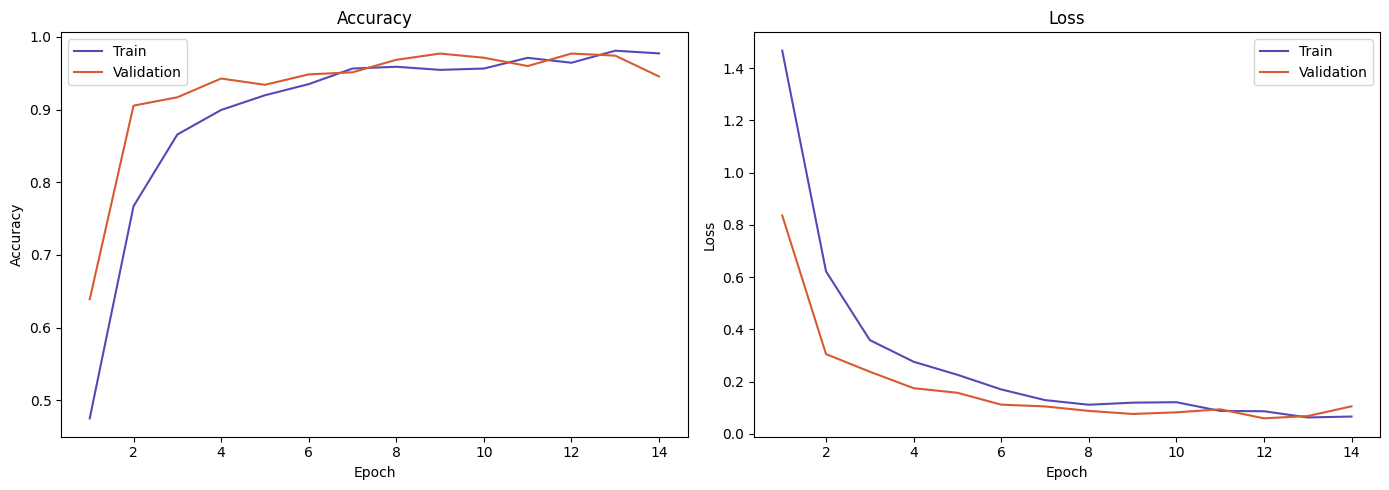

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_acc']) + 1)

ax1.plot(epochs, history['train_acc'], label='Train', color='#534AB7')
ax1.plot(epochs, history['val_acc'], label='Validation', color='#D85A30')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(epochs, history['train_loss'], label='Train', color='#534AB7')
ax2.plot(epochs, history['val_loss'], label='Validation', color='#D85A30')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

### Reading the curves

Both curves track closely, train and validation accuracy climb together and converge around 95-97%. No big gap between them, which means the model is generalizing, not memorizing. The loss plot confirms this: both losses drop together. Validation loss started creeping up slightly around epoch 12, and early stopping caught it at epoch 14. Exactly what it's supposed to do.

## Phase 4: Evaluation

Loading the best model (saved at epoch 12 with 97.7% val accuracy) and testing it on data it has never seen. This is the final exam, the only metric that truly matters.

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

# Load the best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

# Classification report — precision, recall, f1 per class
target_names = ['bebop', 'membo', 'unknown']
print(classification_report(all_labels, all_preds, target_names=target_names))

              precision    recall  f1-score   support

       bebop       0.98      0.98      0.98       100
       membo       0.95      0.97      0.96       100
     unknown       0.98      0.97      0.97       150

    accuracy                           0.97       350
   macro avg       0.97      0.97      0.97       350
weighted avg       0.97      0.97      0.97       350



### Confusion matrix

Shows exactly where the model gets confused, which classes it mixes up. The diagonal should be dark (correct predictions), off-diagonal should be light (mistakes).

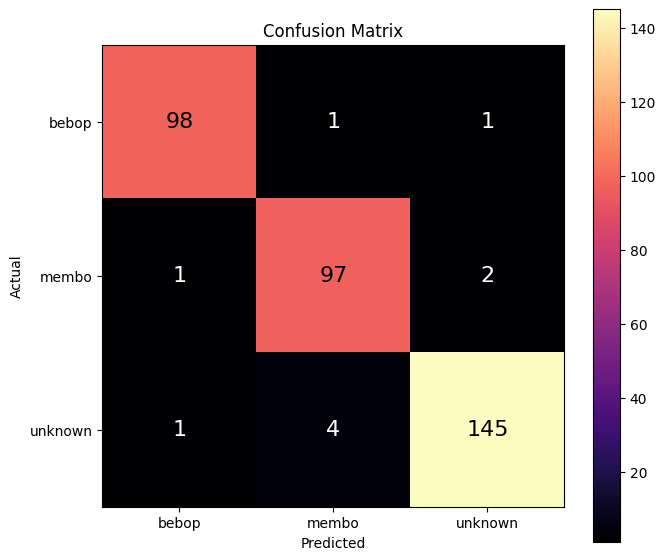

In [20]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='magma')

names = ['bebop', 'membo', 'unknown']
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(names)
ax.set_yticklabels(names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')

# Write numbers in each cell
for i in range(3):
    for j in range(3):
        color = 'white' if cm[i, j] < cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=16)

plt.colorbar(im)
plt.tight_layout()
plt.show()

### Output

Out of 350 test samples, only 10 mistakes total. The interesting part: 4 of those are unknown sounds misclassified as membo. Makes sense, membo is a small drone with high-pitched propellers, some environmental sounds might hit similar frequencies. Bebop and membo almost never get confused with each other (only 1 swap each way), which tells me the model learned the actual harmonic differences between the two drones, not just "this sounds like a drone."

### SNR-based robustness test

Testing the model under noisy conditions by adding white noise to the test set at different Signal-to-Noise Ratios (SNR). A higher SNR means cleaner audio, lower SNR means more noise. This simulates real-world deployment where wind, traffic, and other sounds interfere with drone detection.

In [21]:
def add_noise(audio, snr_db):
    """Add white noise to audio at a specific SNR level.

    SNR (Signal-to-Noise Ratio) in dB:
      20dB = light noise (quiet room)
      10dB = moderate noise (office)
       5dB = heavy noise (busy street)
       0dB = signal and noise are equally loud
    """
    signal_power = np.mean(audio ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(audio))
    return audio + noise

# Test at different noise levels
snr_levels = [20, 10, 5, 0]
results = []

# Get original test audio files for adding noise
test_indices = []
test_audios = []
test_labels_raw = []

multi_path = "./data/DroneAudioDataset/Multiclass_Drone_Audio"
label_map = {"bebop_1": 0, "membo_1": 1, "unknown": 2}

# Rebuild test audio from the same files
all_audios = []
all_labels_list = []

for folder, label in label_map.items():
    folder_path = os.path.join(multi_path, folder)
    for f in os.listdir(folder_path):
        if not f.endswith('.wav'):
            continue
        y_audio, sr = librosa.load(os.path.join(folder_path, f), sr=SAMPLE_RATE)
        if np.abs(y_audio).max() < 0.01:
            continue
        if len(y_audio) < 16000:
            y_audio = np.pad(y_audio, (0, 16000 - len(y_audio)))
        else:
            y_audio = y_audio[:16000]
        all_audios.append(y_audio)
        all_labels_list.append(label)

all_audios = np.array(all_audios)
all_labels_arr = np.array(all_labels_list)

# Use same balanced subset and split
random.seed(42)
unknown_idx = [i for i in range(len(all_labels_arr)) if all_labels_arr[i] == 2]
drone_idx = [i for i in range(len(all_labels_arr)) if all_labels_arr[i] != 2]
selected_unknown = random.sample(unknown_idx, 1000)
keep_idx = drone_idx + selected_unknown

balanced_audios = all_audios[keep_idx]
balanced_labels = all_labels_arr[keep_idx]

_, temp_audio, _, temp_labels = train_test_split(
    balanced_audios, balanced_labels, test_size=0.3, random_state=42, stratify=balanced_labels
)
_, test_audio, _, test_labels_snr = train_test_split(
    temp_audio, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Test samples for SNR test: {len(test_audio)}")

# Test each SNR level
for snr in snr_levels:
    noisy_specs = []
    for audio in test_audio:
        noisy = add_noise(audio, snr)
        mel = librosa.power_to_db(
            librosa.feature.melspectrogram(y=noisy.astype(np.float32), sr=SAMPLE_RATE, n_mels=128),
            ref=np.max
        )
        noisy_specs.append(mel)

    X_noisy = torch.FloatTensor(np.array(noisy_specs)).unsqueeze(1).to(device)

    model.eval()
    with torch.no_grad():
        preds = model(X_noisy).argmax(1).cpu().numpy()

    acc = (preds == test_labels_snr).mean()
    recall = (preds[test_labels_snr != 2] == test_labels_snr[test_labels_snr != 2]).mean()
    results.append({'SNR': f"{snr}dB", 'Accuracy': f"{acc:.3f}", 'Drone Recall': f"{recall:.3f}"})
    print(f"SNR {snr:2d}dB | Accuracy: {acc:.3f} | Drone Recall: {recall:.3f}")

print("\n--- Clean (no noise) ---")
clean_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"Accuracy: {clean_acc:.3f}")

Test samples for SNR test: 350
SNR 20dB | Accuracy: 0.934 | Drone Recall: 0.955
SNR 10dB | Accuracy: 0.889 | Drone Recall: 0.915
SNR  5dB | Accuracy: 0.849 | Drone Recall: 0.870
SNR  0dB | Accuracy: 0.791 | Drone Recall: 0.815

--- Clean (no noise) ---
Accuracy: 0.971


### SNR test results

The model degrades gracefully under noise — even at 0dB (signal and noise equally loud), it still detects drones 81.5% of the time. At 10dB (moderate noise like an office), accuracy stays near 89%. This is a strong result for a simple CNN without any noise-specific training.

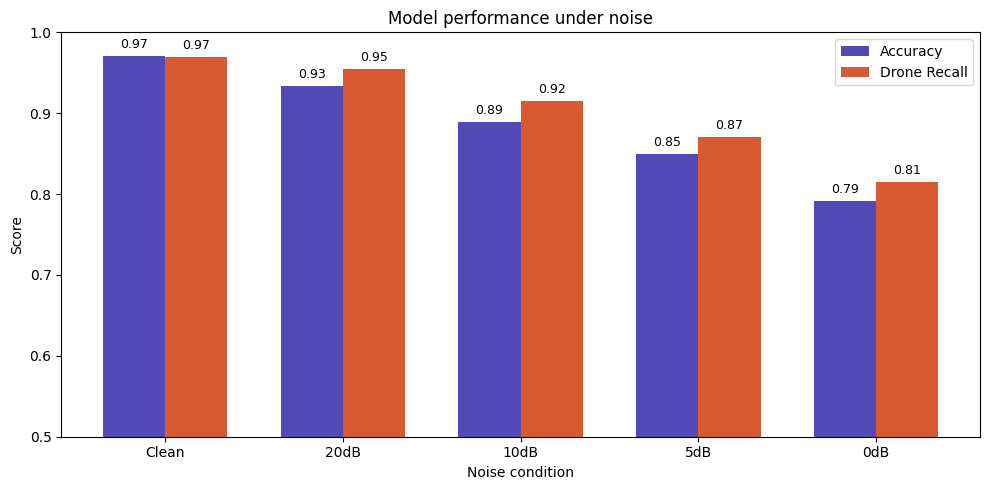

In [22]:
snr_labels = ['Clean', '20dB', '10dB', '5dB', '0dB']
accuracies = [0.971, 0.934, 0.889, 0.849, 0.791]
recalls = [0.97, 0.955, 0.915, 0.870, 0.815]

fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(snr_labels))
width = 0.35

ax.bar([i - width/2 for i in x], accuracies, width, label='Accuracy', color='#534AB7')
ax.bar([i + width/2 for i in x], recalls, width, label='Drone Recall', color='#D85A30')

ax.set_xticks(x)
ax.set_xticklabels(snr_labels)
ax.set_xlabel('Noise condition')
ax.set_ylabel('Score')
ax.set_title('Model performance under noise')
ax.set_ylim(0.5, 1.0)
ax.legend()

# Add values on top of bars
for i, (a, r) in enumerate(zip(accuracies, recalls)):
    ax.text(i - width/2, a + 0.01, f"{a:.2f}", ha='center', fontsize=9)
    ax.text(i + width/2, r + 0.01, f"{r:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Noise robustness takeaway

The key insight here: drone recall stays above accuracy at every noise level. That means when the model makes mistakes under noise, it tends to false-alarm (calling a non-drone a drone) rather than miss an actual drone. For a security system, that's the right failure mode, a false alarm is annoying, a missed drone is dangerous. Even at 0dB where signal and noise are equally loud, the model still catches 81.5% of drones.

## Results summary

| Condition | Accuracy | Drone Recall |
|-----------|----------|--------------|
| Clean     | 97.1%    | 97.0%        |
| 20dB SNR  | 93.4%    | 95.5%        |
| 10dB SNR  | 88.9%    | 91.5%        |
| 5dB SNR   | 84.9%    | 87.0%        |
| 0dB SNR   | 79.1%    | 81.5%        |

### Key findings

1. **97% accuracy on clean data** — the model nails all three classes with balanced precision and recall. Bebop and membo almost never get confused with each other.

2. **Handles noise better than expected** — performance drops as noise increases, but it's a smooth decline, not a cliff. At 10dB (think a noisy office) it still hits 89%. Even at 0dB where signal and noise are equally loud, drone recall is above 80%.

3. **Fails in the right direction** — under noise, the model would rather false-alarm than miss a drone. Drone recall beats overall accuracy at every noise level. For a security system, that's exactly what you want.

4. **Minimal confusion between drone types** — the two drones have distinct enough harmonic signatures that the model rarely mixes them up. Most errors are unknown sounds getting tagged as membo, probably because some environmental sounds hit similar high frequencies.
### What this project doesn't cover (yet)

This was trained on 2 drone models recorded indoors, real deployment would need way more variety. The noise test uses white noise, which is a decent baseline but doesn't capture stuff like wind or traffic that has its own frequency structure. Scaling to a bigger dataset like DADS (180k+ samples, 15+ drones) would help with generalization. And architecturally, there's room to try more powerful models, Audio Spectrogram Transformers or ResNet transfer learning could probably push the noisy-environment numbers up.